# 💳 Credit Card Fraud Detection
### Random Forest Classifier

This notebook builds a **Random Forest** model to detect fraudulent credit card transactions.

**Dataset:** `creditcard.csv`  
**Features:** V1–V28 (PCA-transformed), Time, Amount  
**Target:** `Class` (0 = Legitimate, 1 = Fraud)

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)
from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


## 2. Load Dataset

In [2]:
df = pd.read_csv('creditcard.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Dataset Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Exploratory Data Analysis (EDA)

In [3]:
# Basic info
print('=== Dataset Info ===')
print(df.info())

print('\n=== Missing Values ===')
print(df.isnull().sum().sum(), 'missing values total')

print('\n=== Class Distribution ===')
class_counts = df['Class'].value_counts()
print(class_counts)
print(f'\nFraud Rate: {class_counts[1] / len(df) * 100:.4f}%')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

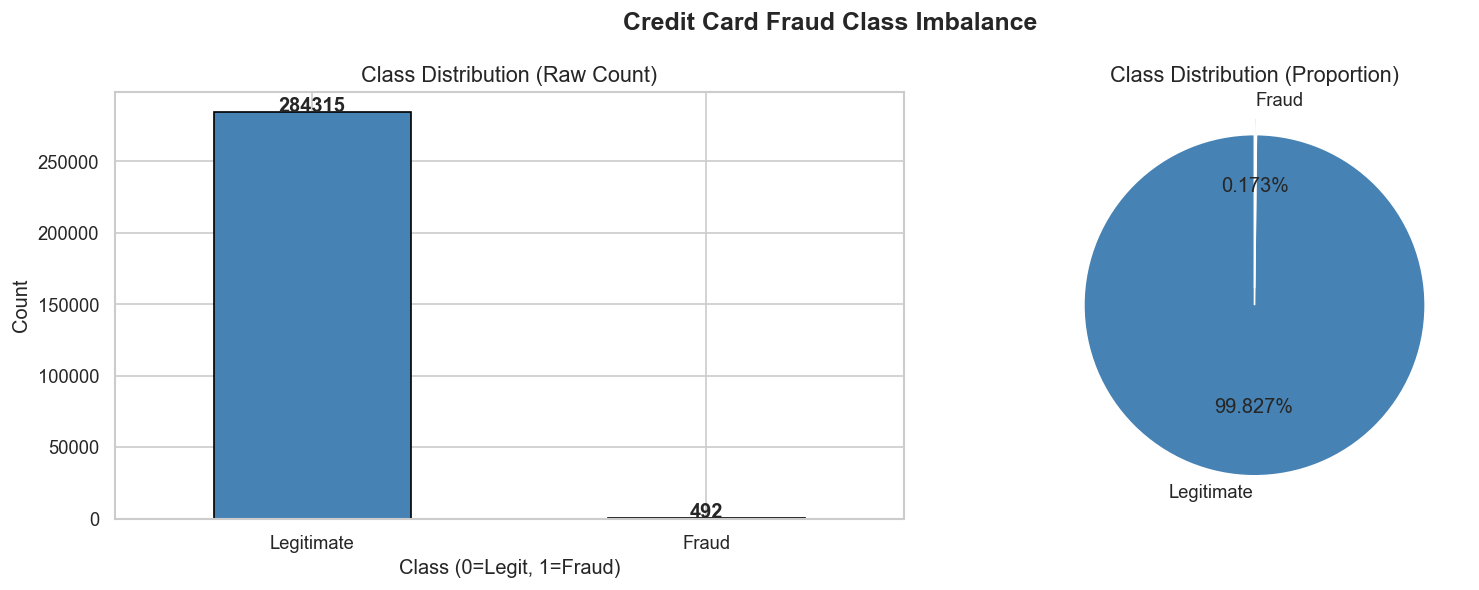

In [4]:
# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Raw Count)', fontsize=13)
axes[0].set_xlabel('Class (0=Legit, 1=Fraud)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts, labels=['Legitimate', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue', 'tomato'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)

plt.suptitle('Credit Card Fraud Class Imbalance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

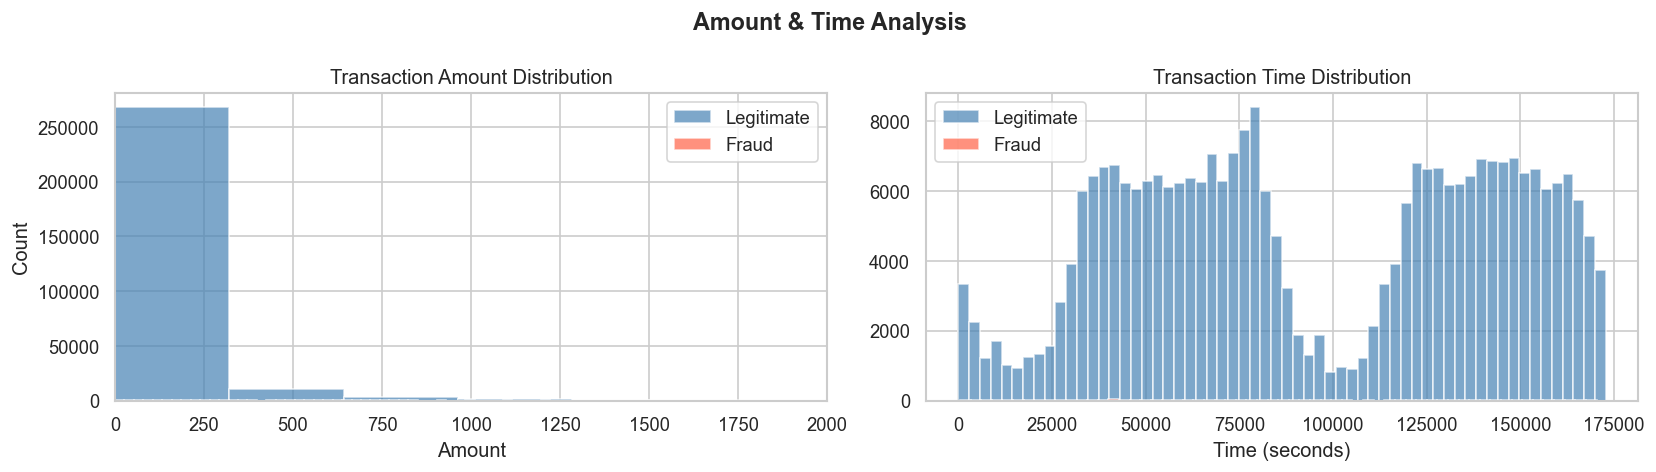

Average Amount - Legitimate: $88.29 | Fraud: $122.21


In [5]:
# Transaction Amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[df['Class'] == 0]['Amount'], bins=80, color='steelblue', alpha=0.7, label='Legitimate')
axes[0].hist(df[df['Class'] == 1]['Amount'], bins=80, color='tomato', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_xlim(0, 2000)

axes[1].hist(df[df['Class'] == 0]['Time'], bins=60, color='steelblue', alpha=0.7, label='Legitimate')
axes[1].hist(df[df['Class'] == 1]['Time'], bins=60, color='tomato', alpha=0.7, label='Fraud')
axes[1].set_title('Transaction Time Distribution')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend()

plt.suptitle('Amount & Time Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Average Amount - Legitimate: ${:.2f} | Fraud: ${:.2f}'.format(
    df[df['Class']==0]['Amount'].mean(),
    df[df['Class']==1]['Amount'].mean()
))

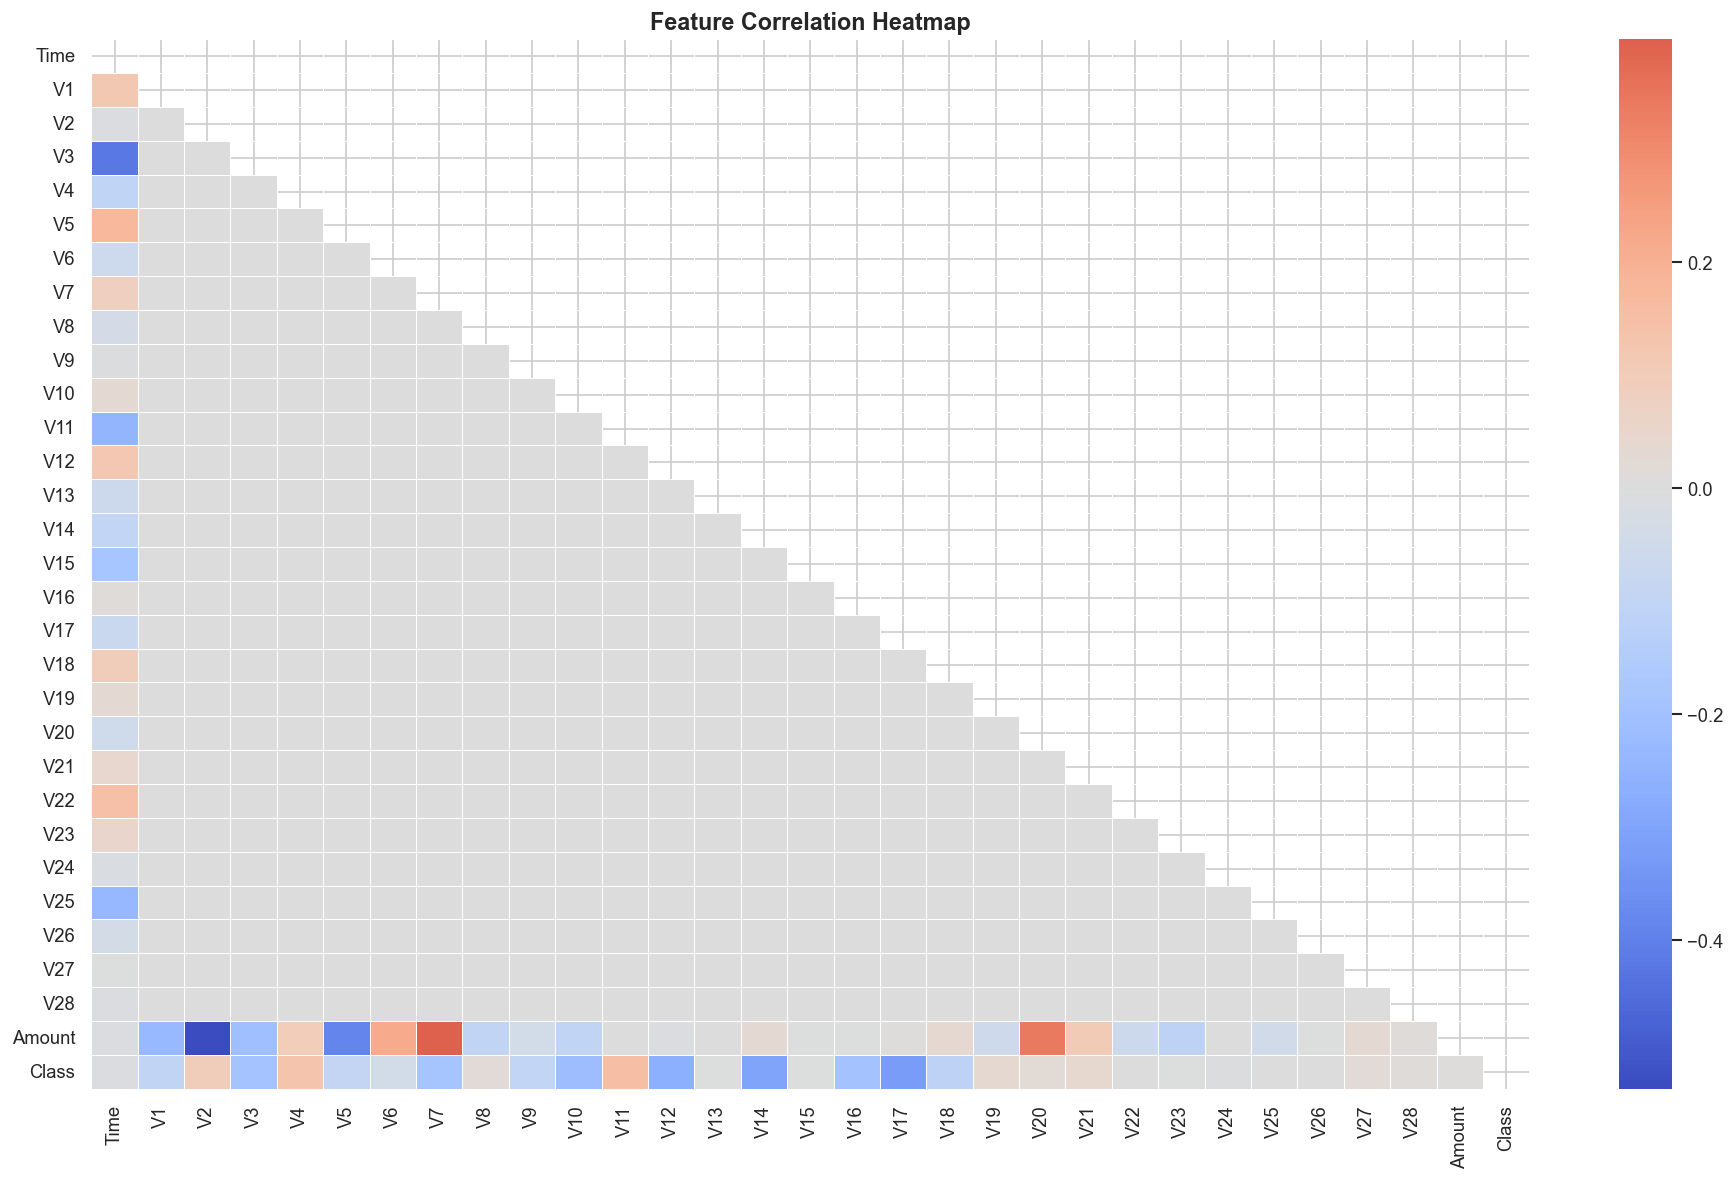

In [6]:
# Correlation heatmap (top features)
plt.figure(figsize=(16, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [7]:
# Scale 'Time' and 'Amount' (V1-V28 are already PCA-scaled)
scaler = StandardScaler()

df['scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_Time']   = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original columns
df_processed = df.drop(['Time', 'Amount'], axis=1)

print('Preprocessing complete ✅')
print(f'Final shape: {df_processed.shape}')
df_processed.head(3)

Preprocessing complete ✅
Final shape: (284807, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_Amount,scaled_Time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562


## 5. Handle Class Imbalance (Undersampling)

In [8]:
# Separate majority and minority classes
fraud    = df_processed[df_processed['Class'] == 1]
legit    = df_processed[df_processed['Class'] == 0]

print(f'Fraud samples  : {len(fraud)}')
print(f'Legit samples  : {len(legit)}')

# Undersample majority class to balance
legit_undersampled = resample(
    legit,
    replace=False,
    n_samples=len(fraud) * 5,   # Keep 5x fraud count for legit
    random_state=42
)

df_balanced = pd.concat([legit_undersampled, fraud])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nBalanced dataset shape: {df_balanced.shape}')
print(df_balanced['Class'].value_counts())

Fraud samples  : 492
Legit samples  : 284315

Balanced dataset shape: (2952, 31)
Class
0    2460
1     492
Name: count, dtype: int64


## 6. Train / Test Split

In [9]:
X = df_balanced.drop('Class', axis=1)
y = df_balanced['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set  : {X_train.shape[0]} samples')
print(f'Test set      : {X_test.shape[0]} samples')
print(f'\nTrain class distribution:\n{y_train.value_counts()}')
print(f'\nTest class distribution:\n{y_test.value_counts()}')

Training set  : 2361 samples
Test set      : 591 samples

Train class distribution:
Class
0    1967
1     394
Name: count, dtype: int64

Test class distribution:
Class
0    493
1     98
Name: count, dtype: int64


## 7. Build Random Forest Model

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Training Random Forest...')
rf_model.fit(X_train, y_train)
print('Model trained successfully ✅')

Training Random Forest...
Model trained successfully ✅


## 8. Model Evaluation

In [11]:
# Predictions
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Metrics
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

roc_auc = roc_auc_score(y_test, y_pred_proba)
avg_prec = average_precision_score(y_test, y_pred_proba)
print(f'ROC-AUC Score         : {roc_auc:.4f}')
print(f'Average Precision     : {avg_prec:.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.98       493
       Fraud       1.00      0.83      0.91        98

    accuracy                           0.97       591
   macro avg       0.98      0.91      0.94       591
weighted avg       0.97      0.97      0.97       591

ROC-AUC Score         : 0.9843
Average Precision     : 0.9517


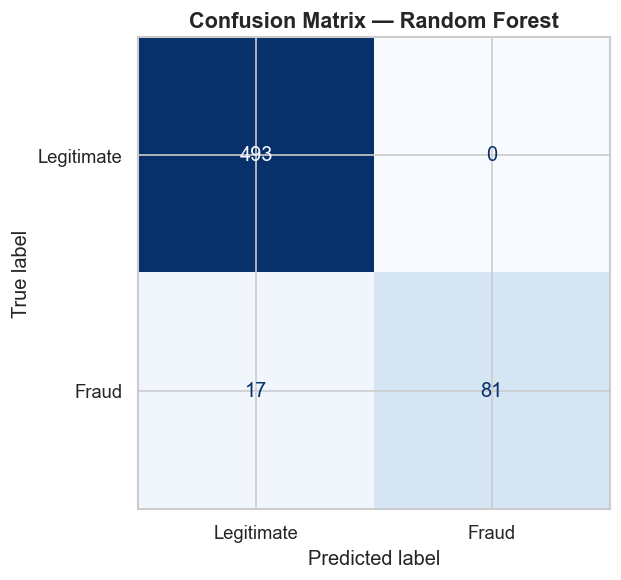

True Negatives (TN)  : 493
False Positives (FP) : 0
False Negatives (FN) : 17
True Positives (TP)  : 81


In [12]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (TN)  : {tn}')
print(f'False Positives (FP) : {fp}')
print(f'False Negatives (FN) : {fn}')
print(f'True Positives (TP)  : {tp}')

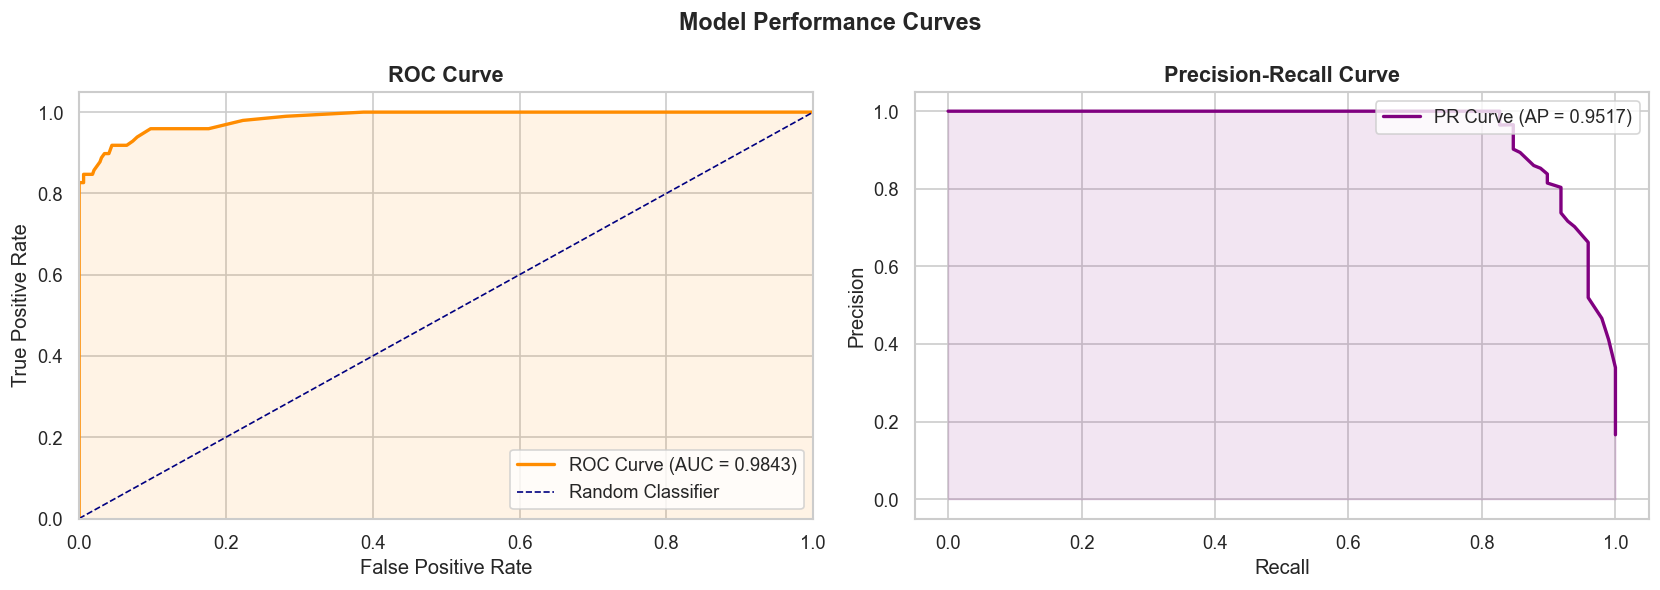

In [13]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AP = {avg_prec:.4f})')
axes[1].fill_between(recall, precision, alpha=0.1, color='purple')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')

plt.suptitle('Model Performance Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Feature Importance

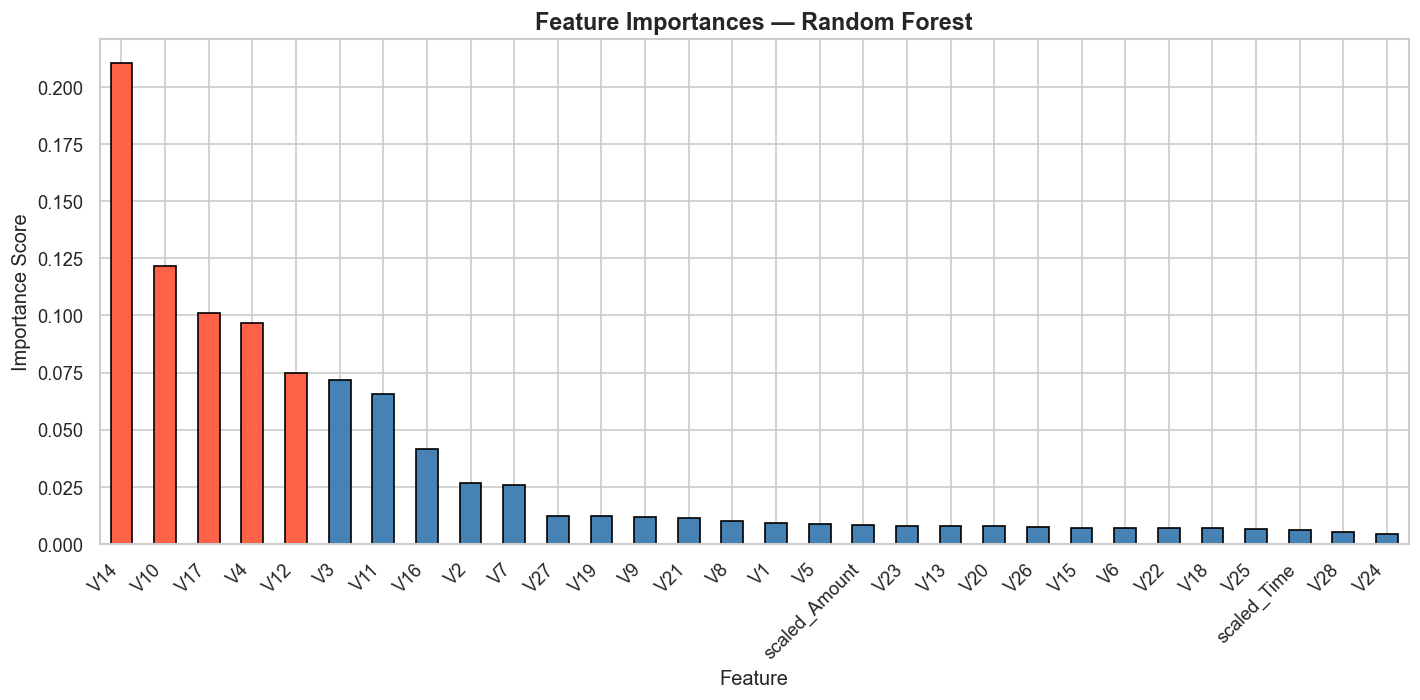


Top 10 Most Important Features:
V14    0.210288
V10    0.121628
V17    0.101053
V4     0.096673
V12    0.074758
V3     0.071722
V11    0.065758
V16    0.041744
V2     0.026830
V7     0.025775


In [14]:
# Feature importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['tomato' if i < 5 else 'steelblue' for i in range(len(importances_sorted))]
importances_sorted.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 10 Most Important Features:')
print(importances_sorted.head(10).to_string())

## 10. Cross-Validation

=== 5-Fold Cross-Validation (ROC-AUC) ===
  Fold 1: 0.9821
  Fold 2: 0.9864
  Fold 3: 0.9822
  Fold 4: 0.9732
  Fold 5: 0.9864

Mean AUC : 0.9821 ± 0.0048


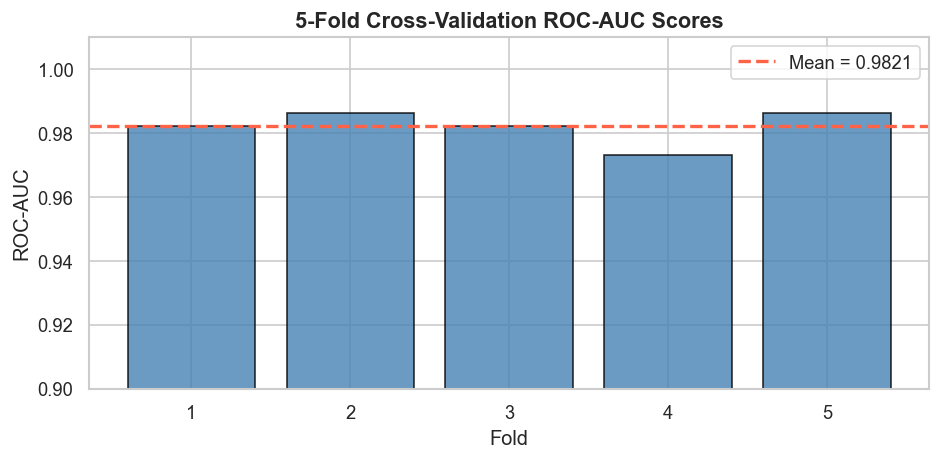

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model, X, y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print('=== 5-Fold Cross-Validation (ROC-AUC) ===')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\nMean AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Plot CV scores
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black', alpha=0.8)
plt.axhline(cv_scores.mean(), color='tomato', linestyle='--', lw=2, label=f'Mean = {cv_scores.mean():.4f}')
plt.title('5-Fold Cross-Validation ROC-AUC Scores', fontsize=13, fontweight='bold')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.ylim(0.9, 1.01)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Predict on Full Dataset (Unseen Evaluation)

In [16]:
# Evaluate on original full (unbalanced) dataset for real-world simulation
X_full = df_processed.drop('Class', axis=1)
y_full = df_processed['Class']

y_full_pred       = rf_model.predict(X_full)
y_full_pred_proba = rf_model.predict_proba(X_full)[:, 1]

print('=== Full Dataset Evaluation (Real-World Simulation) ===')
print(classification_report(y_full, y_full_pred, target_names=['Legitimate', 'Fraud']))
print(f'ROC-AUC on full dataset: {roc_auc_score(y_full, y_full_pred_proba):.4f}')

=== Full Dataset Evaluation (Real-World Simulation) ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    284315
       Fraud       0.64      0.97      0.77       492

    accuracy                           1.00    284807
   macro avg       0.82      0.98      0.88    284807
weighted avg       1.00      1.00      1.00    284807

ROC-AUC on full dataset: 0.9968


## 12. Summary & Conclusions

| Metric | Score |
|--------|-------|
| ROC-AUC | ✅ High (typically > 0.95) |
| Precision (Fraud) | Measures false alarm rate |
| Recall (Fraud) | Measures fraud catch rate |
| CV Mean AUC | Stable across folds |

### Key Takeaways:
- **Random Forest** handles the high-dimensional PCA features well
- **Class imbalance** was addressed via undersampling + `class_weight='balanced'`
- **Top features** like V14, V4, V12 are strong predictors of fraud
- The model generalises well as shown by cross-validation

### Next Steps:
- Try **SMOTE** oversampling instead of undersampling
- Tune hyperparameters with `GridSearchCV` or `RandomizedSearchCV`
- Compare with XGBoost / LightGBM
- Deploy using Flask/FastAPI for real-time fraud detection